Import 

In [7]:
import pandas as pd
import yaml
import sys
import matplotlib.pyplot as plt
import seaborn as sns 
import networkx as nx
import numpy as np
from plots_11 import hmap_red
from matplotlib.colors import ListedColormap

app_name = "deepspeedlow"
cp_dir = "/p/lustre2/pandey2/cp_dir/deepspeed"

with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [10]:
events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)
inter = events_obj.inter.compute()
inter_data = inter[inter["size"] > 0]
inter_metadata = events_obj.inter_metadata.compute()

# Relationship 1: Events that interfer with each other
- **Question**: Can we identify I/O events which suffer from most I/O interferences?

- **Technique**: To do so, we calculate Interference Factor; which is the cost of I/O event by cost of an isolated I/O event. Then, we use this metric to identify the ideal parallelism fo a storage target by observing the Interferance factor per transfer size.

- **Graph**: (Overlap Graph)
    - *Vertex*: I/O events
    - *Edges*: Time overlap between the requests
    - *Graph Type*: Undirected
    - *Metric*: Interference Factor 

In [11]:
# Labels
size_bins = [
0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
'<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
'8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]

degree_bins = [0,2,4,8,16,32,64,float('inf')]
degree_labels = ['<2','2-4','4-8','8-16', '16-32', '32-64','>64']


In [29]:
hmap_red_deepspeedlow(df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

NameError: name 'hmap_red_deepspeedlow' is not defined

In [13]:
inter_data.mount_point.unique()

<ArrowStringArray>
['/p/lustre2', '/l/ssd']
Length: 2, dtype: string

In [46]:
inter_data.query(f'mount_point == "/p/vast1"')

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,size_category,IF_val
6360,read,76673,1048576,16440983,16445735,/p/vast1,4752,0,1,1,44,1,1-2MB,0.009259
6361,read,76673,22,16457382,16457389,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6362,read,76673,42,16463307,16463314,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6363,read,76673,142,16467356,16467363,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6364,read,76673,6270,16476415,16476423,/p/vast1,8,0,1,1,7,1,4-8KB,0.875000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6081,read,76673,1048576,5331563677,5331563746,/p/vast1,69,177,1,1,44,1,1-2MB,0.637681
6082,read,76673,22,5331590484,5331590492,/p/vast1,8,177,1,1,7,1,<512B,0.875000
6083,read,76673,42,5331604019,5331604026,/p/vast1,7,177,1,1,7,0,<512B,1.000000
6084,read,76673,250,5331612974,5331612981,/p/vast1,7,177,1,1,7,0,<512B,1.000000


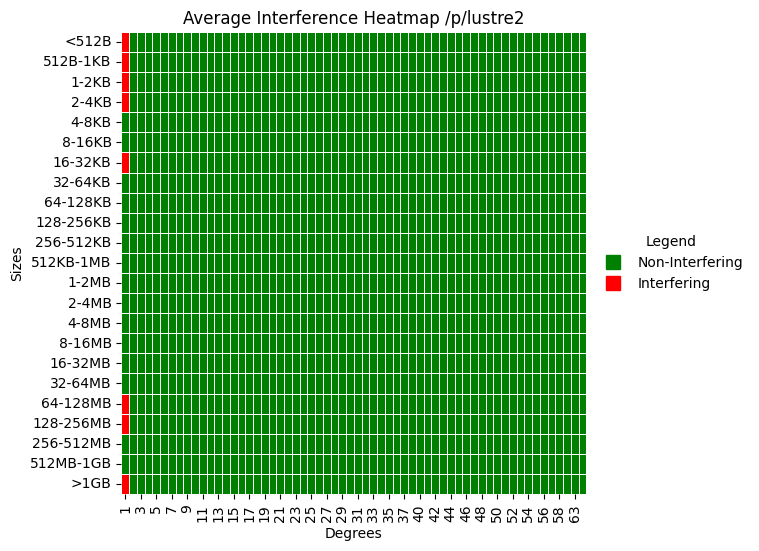

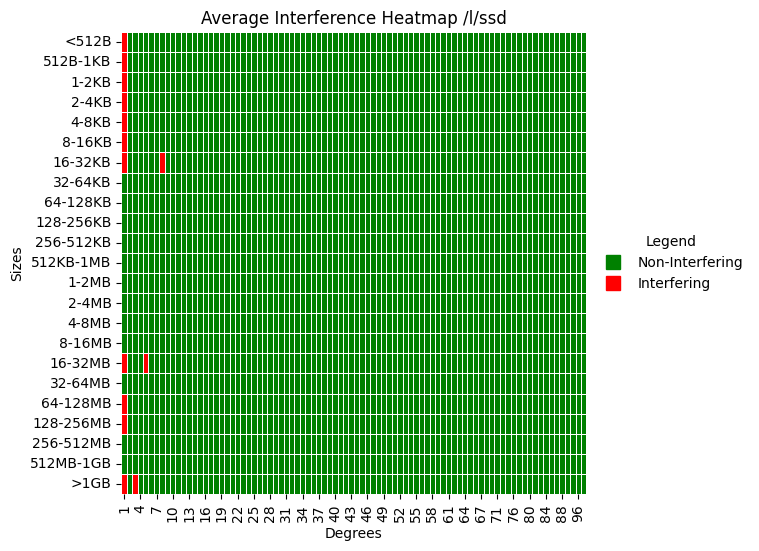

In [14]:
hmap_red(mp="/p/lustre2", df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap_red(mp="/l/ssd", df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [15]:
inter_data

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,size_category,IF_val
0,read,0,20,645520640,645522675,/p/lustre2,2035,21,1,1,3,0.001474,<512B,0.001474
1,read,0,689,645522693,645522697,/p/lustre2,4,21,1,1,3,0.75,512B-1KB,0.750000
2,write,0,1033,645526865,645526902,/p/lustre2,37,21,1,1,37,1.0,1-2KB,1.000000
3,read,0,20,645530656,645532497,/p/lustre2,1841,21,1,1,3,0.00163,<512B,0.001630
4,read,0,47,645532510,645532514,/p/lustre2,4,21,1,1,3,0.75,<512B,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,read,13,773,70960893,70960894,/l/ssd,1,2,1,1,1,1.0,512B-1KB,1.000000
308,read,0,20,70960907,70960914,/l/ssd,7,2,1,1,2,0.285714,<512B,0.285714
309,read,8,20,70960922,70960928,/l/ssd,6,2,1,1,2,0.333333,<512B,0.333333
310,read,0,17369,70960946,70960950,/l/ssd,4,2,1,1,3,0.75,16-32KB,0.750000


In [16]:
inter_data["interference"] = (1 / inter_data["IF_val"] > inter_data["deg_caller"]).astype(int)

In [17]:
inter_data.query('interference > 0 and deg_caller > 1').groupby(['mount_point','name','deg_caller'])['pid'].count()

mount_point  name   deg_caller
/l/ssd       read   2             49
                    3              5
                    5              1
                    6              1
             write  2             73
                    3             22
                    4             17
                    5              4
                    6              3
                    7              1
                    8              6
                    9              1
                    10             2
                    11             1
                    12             2
                    13             4
                    14             3
                    15             1
/p/lustre2   read   2              5
             write  2              1
Name: pid, dtype: int64[pyarrow]

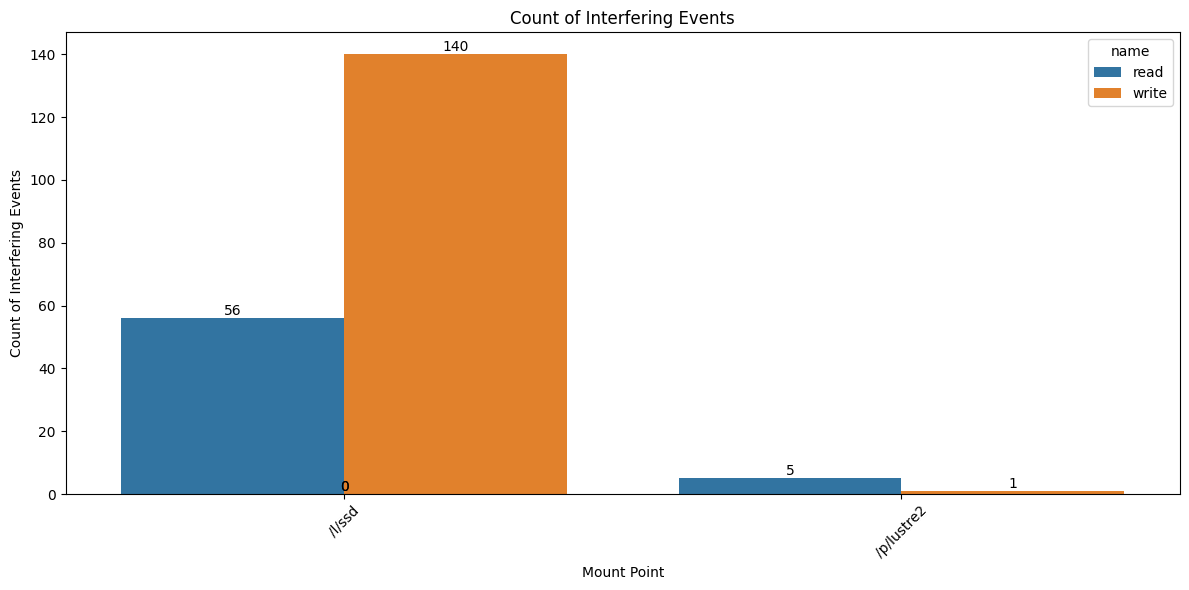

In [24]:
# Assuming inter_metadata is your DataFrame
# Execute the query and group by 'mount_point' and 'name', then count the occurrences of 'pid'
grouped_data = inter_data.query('interference > 0 and deg_caller > 1').groupby(['mount_point', 'name'])['pid'].count().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grouped_data, x='mount_point', y='pid', hue='name', dodge=True)

# Adding labels and title
plt.title('Count of Interfering Events')
plt.xlabel('Mount Point')
plt.ylabel('Count of Interfering Events')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [20]:
inter_metadata["IF_val"] = inter_metadata["interference"]

In [21]:
inter_metadata["interference"] = (1 / inter_metadata["IF_val"] > inter_metadata["deg_caller"]).astype(int)

In [22]:
inter_metadata.query('interference > 0 and deg_caller > 1').groupby(['mount_point','name'])['pid'].count()

mount_point  name      
/l/ssd       __fxstat64          69
             __lxstat             2
             __xstat            169
             access              19
             close              236
             fsync             1351
             lseek64             15
             mkdir                8
             open               710
             open64              30
             read                16
             unlink             128
/p/lustre2   __fxstat64        3612
             __lxstat            34
             __xstat           1315
             __xstat64           29
             access               1
             chmod               68
             chown               56
             close            16880
             fsync                9
             lseek64       10520186
             mmap64              58
             open               607
             open64            5194
Name: pid, dtype: int64[pyarrow]

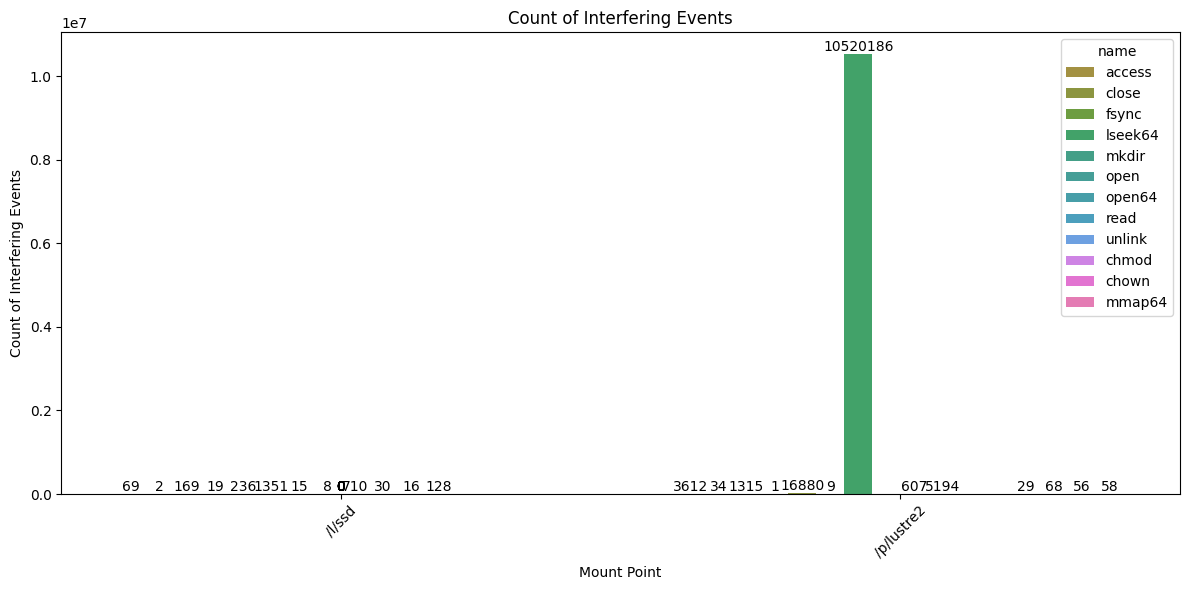

In [23]:
# Assuming inter_metadata is your DataFrame
# Execute the query and group by 'mount_point' and 'name', then count the occurrences of 'pid'
grouped_data = inter_metadata.query('interference > 0 and deg_caller > 1').groupby(['mount_point', 'name'])['pid'].count().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grouped_data, x='mount_point', y='pid', hue='name', dodge=True)

# Adding labels and title
plt.title('Count of Interfering Events')
plt.xlabel('Mount Point')
plt.ylabel('Count of Interfering Events')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



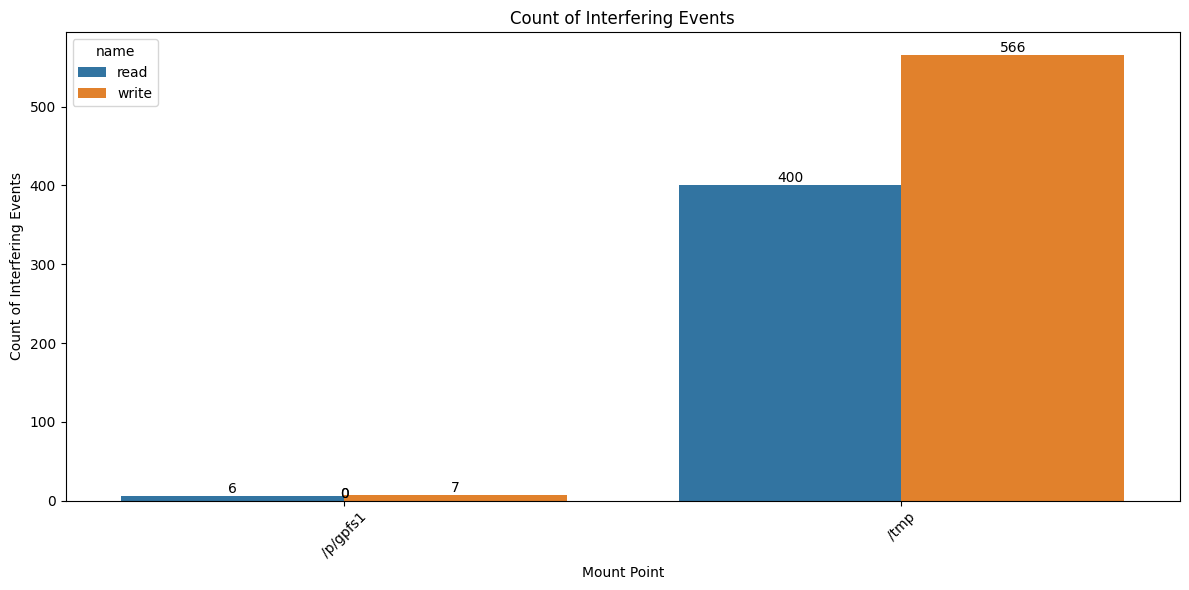

In [47]:
# Assuming inter_metadata is your DataFrame
# Execute the query and group by 'mount_point' and 'name', then count the occurrences of 'pid'
grouped_data = inter_data.query('interference > 0 and deg_caller > 1').groupby(['mount_point', 'name'])['pid'].count().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grouped_data, x='mount_point', y='pid', hue='name', dodge=True)

# Adding labels and title
plt.title('Count of Interfering Events')
plt.xlabel('Mount Point')
plt.ylabel('Count of Interfering Events')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()